# Model Accuracy Evaluation on Taguchi Dataset

## Overview

This notebook evaluates the trained models (GCN and Transformer) on the taguchi dataset by:
1. Loading all trained models from different sampling strategies (random, LHS, Sobol)
2. Making predictions on all taguchi samples
3. Computing accuracy metrics (MAE, RMSE, R², Peak Signal-to-Noise Ratio)
4. Creating "Prediction vs Simulated" comparison visualizations

The evaluation measure both displacement and stress field predictions.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import keras
import warnings
warnings.filterwarnings('ignore')

# Configure visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

# Define paths
data_dir = Path("mock_data")
model_dir = Path("models")
test_data = "taguchi"  # Dataset for evaluation

# Configuration
model_types = ["gcn", "transformer"]
samplings = ["random", "lhs", "sobol"]

print("✓ Setup complete!")
print(f"  Evaluating on: {test_data.upper()} dataset")
print(f"  Model types: {', '.join(model_types)}")
print(f"  Sampling strategies: {', '.join(samplings)}")

✓ Setup complete!
  Evaluating on: TAGUCHI dataset
  Model types: gcn, transformer
  Sampling strategies: random, lhs, sobol


## Step 1: Load Test Data

Load the taguchi dataset and prepare it for evaluation.

In [2]:
# Load test data directory
test_dir = data_dir / test_data
print(f"Loading {test_data.upper()} dataset...")

# Find all sample indices
sample_files = sorted(test_dir.glob("sample_*_params.npy"))
sample_indices = [int(f.stem.split('_')[1]) for f in sample_files]
print(f"✓ Found {len(sample_indices)} test samples")

# Load all test samples
test_params = []
test_displacements = []
test_stresses = []

for idx in sample_indices:
    params = np.load(test_dir / f"sample_{idx}_params.npy")
    disp = np.load(test_dir / f"sample_{idx}_disp.npy")
    stress = np.load(test_dir / f"sample_{idx}_stress.npy")
    
    test_params.append(params)
    test_displacements.append(disp.flatten())  # Flatten to 1D
    test_stresses.append(stress.flatten())     # Flatten to 1D

# Stack into arrays
test_params = np.array(test_params)
test_displacements = np.array(test_displacements)
test_stresses = np.array(test_stresses)

print(f"\nTest data loaded:")
print(f"  Parameters shape: {test_params.shape}")
print(f"  Displacements shape: {test_displacements.shape}")
print(f"  Stresses shape: {test_stresses.shape}")

Loading TAGUCHI dataset...
✓ Found 256 test samples

Test data loaded:
  Parameters shape: (256, 4)
  Displacements shape: (256, 2268)
  Stresses shape: (256, 756)


## Step 2: Evaluate Models

Make predictions using all trained models and compute accuracy metrics.

In [3]:
def compute_metrics(y_true, y_pred):
    """Compute evaluation metrics"""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    
    # Peak Signal-to-Noise Ratio
    mse = mean_squared_error(y_true, y_pred)
    max_val = np.max(y_true)
    psnr = 20 * np.log10(max_val / np.sqrt(mse)) if mse > 0 else float('inf')
    
    return {
        'mae': mae,
        'rmse': rmse,
        'r2': r2,
        'psnr': psnr,
        'mse': mse
    }

def load_model_and_predict(model_dir_path, test_params):
    """Load trained models and make predictions on test data."""
    import os
    from src.rom_model import build_beam_adjacency, GCNLayer, PositionalEmbedding
    
    model_dir_str = str(model_dir_path)
    
    # Custom objects for Keras deserialization
    custom_objs = {
        "GCNLayer": GCNLayer,
        "PositionalEmbedding": PositionalEmbedding
    }
    
    # Load Keras models
    model_disp = keras.models.load_model(
        os.path.join(model_dir_str, "rom_disp.keras"),
        compile=False,
        custom_objects=custom_objs,
        safe_mode=False
    )
    model_stress = keras.models.load_model(
        os.path.join(model_dir_str, "rom_stress.keras"),
        compile=False,
        custom_objects=custom_objs,
        safe_mode=False
    )
    
    # Load saved scaler statistics
    scaler_mean = np.load(os.path.join(model_dir_str, "scaler_mean.npy"))
    scaler_std = np.load(os.path.join(model_dir_str, "scaler_std.npy"))
    
    # Detect model type
    model_type_arr = np.load(os.path.join(model_dir_str, "model_type.npy"), allow_pickle=True)
    model_type = str(model_type_arr[0])
    
    # Build adjacency matrix if needed
    A_hat = None
    if model_type in ("gcn", "transformer"):
        A_hat = build_beam_adjacency(21, 6, 6)
    
    # Scale input parameters
    params_scaled = ((test_params - scaler_mean) / scaler_std).astype(np.float32)
    
    # Prepare model inputs
    if model_type in ("mlp", "transformer"):
        model_inputs = params_scaled
    else:  # GCN
        B = params_scaled.shape[0]
        A_batch = np.tile(A_hat[np.newaxis], (B, 1, 1))
        model_inputs = [params_scaled, A_batch]
    
    # Make predictions
    pred_disp = model_disp.predict(model_inputs, verbose=0)
    pred_stress = model_stress.predict(model_inputs, verbose=0)
    
    return pred_disp, pred_stress

# Store results for all models
results = {}

print(f"{'='*80}")
print("Evaluating Models on Taguchi Dataset")
print(f"{'='*80}\n")

for model_type in model_types:
    for sampling in samplings:
        model_path = model_dir / model_type / sampling
        
        if not model_path.exists():
            print(f"⚠ Model not found: {model_path}")
            continue
        
        print(f"Evaluating {model_type.upper()} with {sampling.upper()} sampling...")
        
        try:
            # Load models and make predictions
            pred_disp, pred_stress = load_model_and_predict(model_path, test_params)
            
            # Compute metrics
            disp_metrics = compute_metrics(test_displacements, pred_disp)
            stress_metrics = compute_metrics(test_stresses, pred_stress)
            
            # Store results
            key = f"{model_type}_{sampling}"
            results[key] = {
                'pred_disp': pred_disp,
                'pred_stress': pred_stress,
                'true_disp': test_displacements,
                'true_stress': test_stresses,
                'disp_metrics': disp_metrics,
                'stress_metrics': stress_metrics,
                'params': test_params
            }
            
            # Print metrics
            print(f"  ✓ Displacement - MAE: {disp_metrics['mae']:.4f}, RMSE: {disp_metrics['rmse']:.4f}, R²: {disp_metrics['r2']:.4f}")
            print(f"  ✓ Stress       - MAE: {stress_metrics['mae']:.4f}, RMSE: {stress_metrics['rmse']:.4f}, R²: {stress_metrics['r2']:.4f}\n")
            
        except Exception as e:
            print(f"  ✗ Error evaluating model: {str(e)}\n")
            import traceback
            traceback.print_exc()
            continue

print(f"{'='*80}")
print(f"Evaluation complete! Results stored for {len(results)} models.")
print(f"{'='*80}")

Evaluating Models on Taguchi Dataset

Evaluating GCN with RANDOM sampling...

  ✓ Displacement - MAE: 0.0846, RMSE: 0.8130, R²: 0.3043
  ✓ Stress       - MAE: 3.1665, RMSE: 11.3028, R²: 0.9025

Evaluating GCN with LHS sampling...
  ✓ Displacement - MAE: 0.0938, RMSE: 0.7358, R²: 0.3029
  ✓ Stress       - MAE: 3.0007, RMSE: 9.1210, R²: 0.9041

Evaluating GCN with SOBOL sampling...
  ✓ Displacement - MAE: 0.1007, RMSE: 0.9793, R²: 0.2963
  ✓ Stress       - MAE: 2.7662, RMSE: 9.3795, R²: 0.9057

Evaluating TRANSFORMER with RANDOM sampling...
  ✓ Displacement - MAE: 0.1242, RMSE: 1.5645, R²: 0.2687
  ✓ Stress       - MAE: 3.8122, RMSE: 22.8750, R²: 0.8523

Evaluating TRANSFORMER with LHS sampling...
  ✓ Displacement - MAE: 0.1509, RMSE: 1.4267, R²: 0.2676
  ✓ Stress       - MAE: 3.0097, RMSE: 18.2597, R²: 0.8772

Evaluating TRANSFORMER with SOBOL sampling...
  ✓ Displacement - MAE: 0.0920, RMSE: 1.4638, R²: 0.2753
  ✓ Stress       - MAE: 2.8831, RMSE: 16.0589, R²: 0.8810

Evaluation comple

## Step 3: Prediction vs Simulated Visualizations

Create scatter plots comparing predicted vs ground truth values for all models.

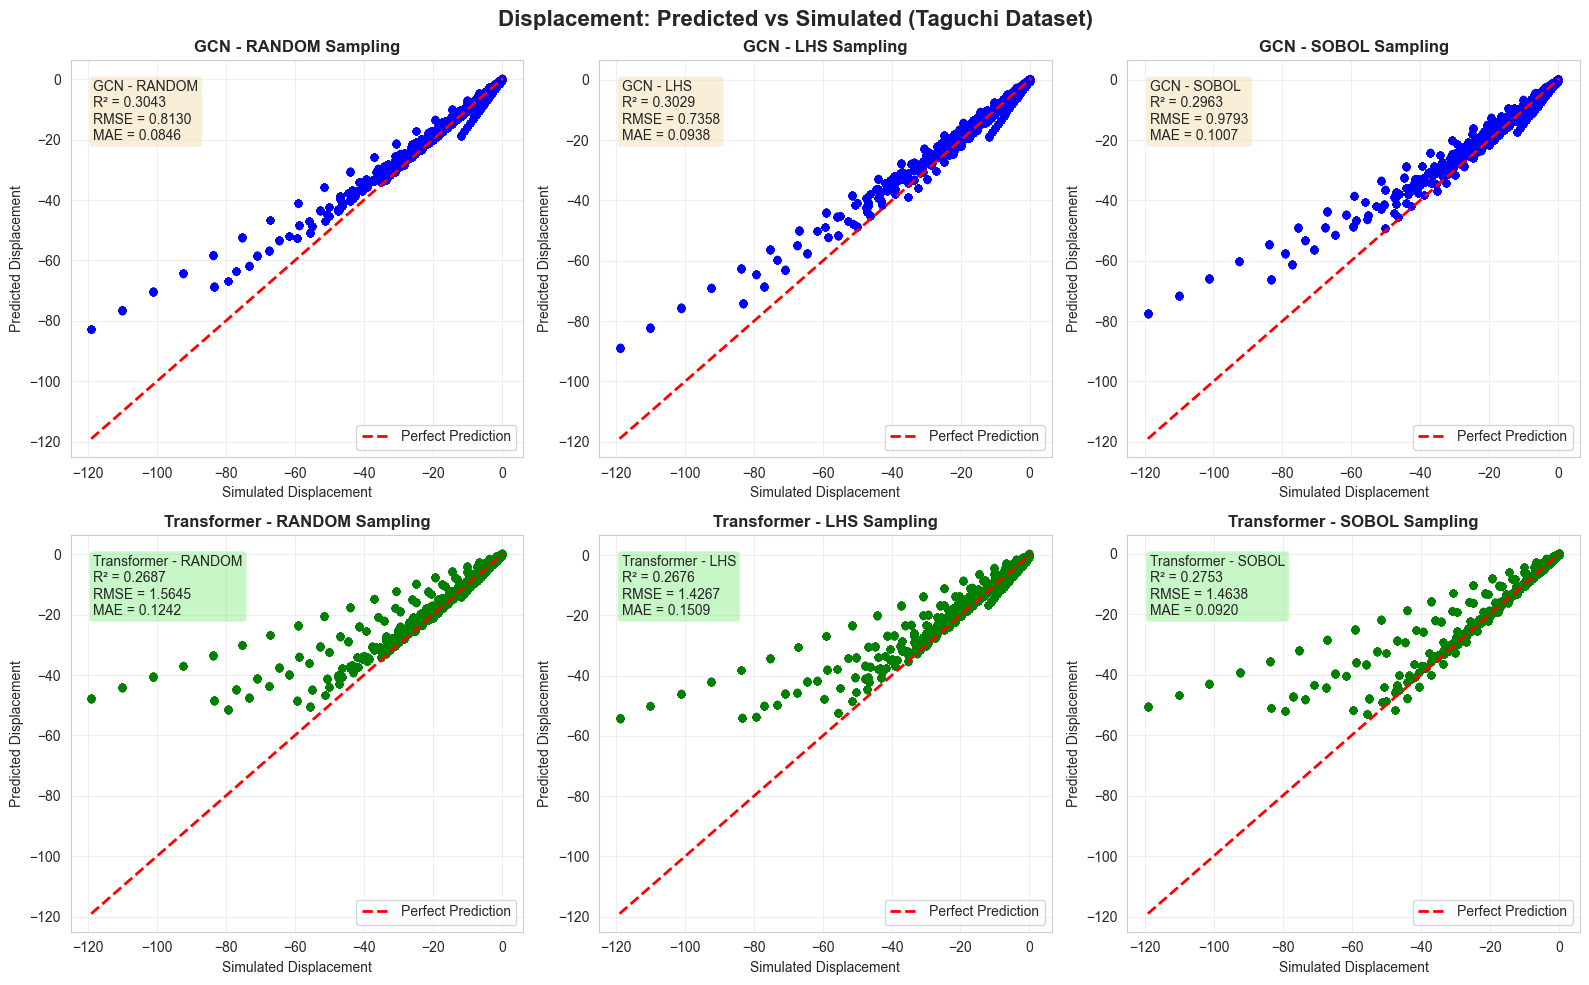

✓ Displacement comparison plots saved to: predictions_displacement_comparison.png


In [6]:
# Create prediction vs simulated plots for DISPLACEMENT
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Displacement: Predicted vs Simulated (Taguchi Dataset)', fontsize=16, fontweight='bold')
axes = axes.flatten()

for idx, sampling in enumerate(samplings):
    key = f"gcn_{sampling}"
    
    if key in results:
        data = results[key]
        true_vals = data['true_disp']
        pred_vals = data['pred_disp']
        metrics = data['disp_metrics']
        
        ax = axes[idx]
        
        # Flatten for scatter plot
        true_flat = true_vals.flatten()
        pred_flat = pred_vals.flatten()
        
        # Scatter plot
        ax.scatter(true_flat, pred_flat, alpha=0.5, s=20, color='blue')
        
        # Perfect prediction line
        min_val = min(true_flat.min(), pred_flat.min())
        max_val = max(true_flat.max(), pred_flat.max())
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
        
        # Add metrics text
        textstr = f"GCN - {sampling.upper()}\n"
        textstr += f"R² = {metrics['r2']:.4f}\n"
        textstr += f"RMSE = {metrics['rmse']:.4f}\n"
        textstr += f"MAE = {metrics['mae']:.4f}"
        
        ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=10,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        
        ax.set_xlabel('Simulated Displacement', fontsize=10)
        ax.set_ylabel('Predicted Displacement', fontsize=10)
        ax.set_title(f'GCN - {sampling.upper()} Sampling', fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3)

# Plot transformer models on the right
for idx, sampling in enumerate(samplings):
    key = f"transformer_{sampling}"
    
    if key in results:
        data = results[key]
        true_vals = data['true_disp']
        pred_vals = data['pred_disp']
        metrics = data['disp_metrics']
        
        ax = axes[3 + idx]
        
        # Flatten for scatter plot
        true_flat = true_vals.flatten()
        pred_flat = pred_vals.flatten()
        
        # Scatter plot
        ax.scatter(true_flat, pred_flat, alpha=0.5, s=20, color='green')
        
        # Perfect prediction line
        min_val = min(true_flat.min(), pred_flat.min())
        max_val = max(true_flat.max(), pred_flat.max())
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
        
        # Add metrics text
        textstr = f"Transformer - {sampling.upper()}\n"
        textstr += f"R² = {metrics['r2']:.4f}\n"
        textstr += f"RMSE = {metrics['rmse']:.4f}\n"
        textstr += f"MAE = {metrics['mae']:.4f}"
        
        ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=10,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))
        
        ax.set_xlabel('Simulated Displacement', fontsize=10)
        ax.set_ylabel('Predicted Displacement', fontsize=10)
        ax.set_title(f'Transformer - {sampling.upper()} Sampling', fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('predictions_displacement_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Displacement comparison plots saved to: predictions_displacement_comparison.png")

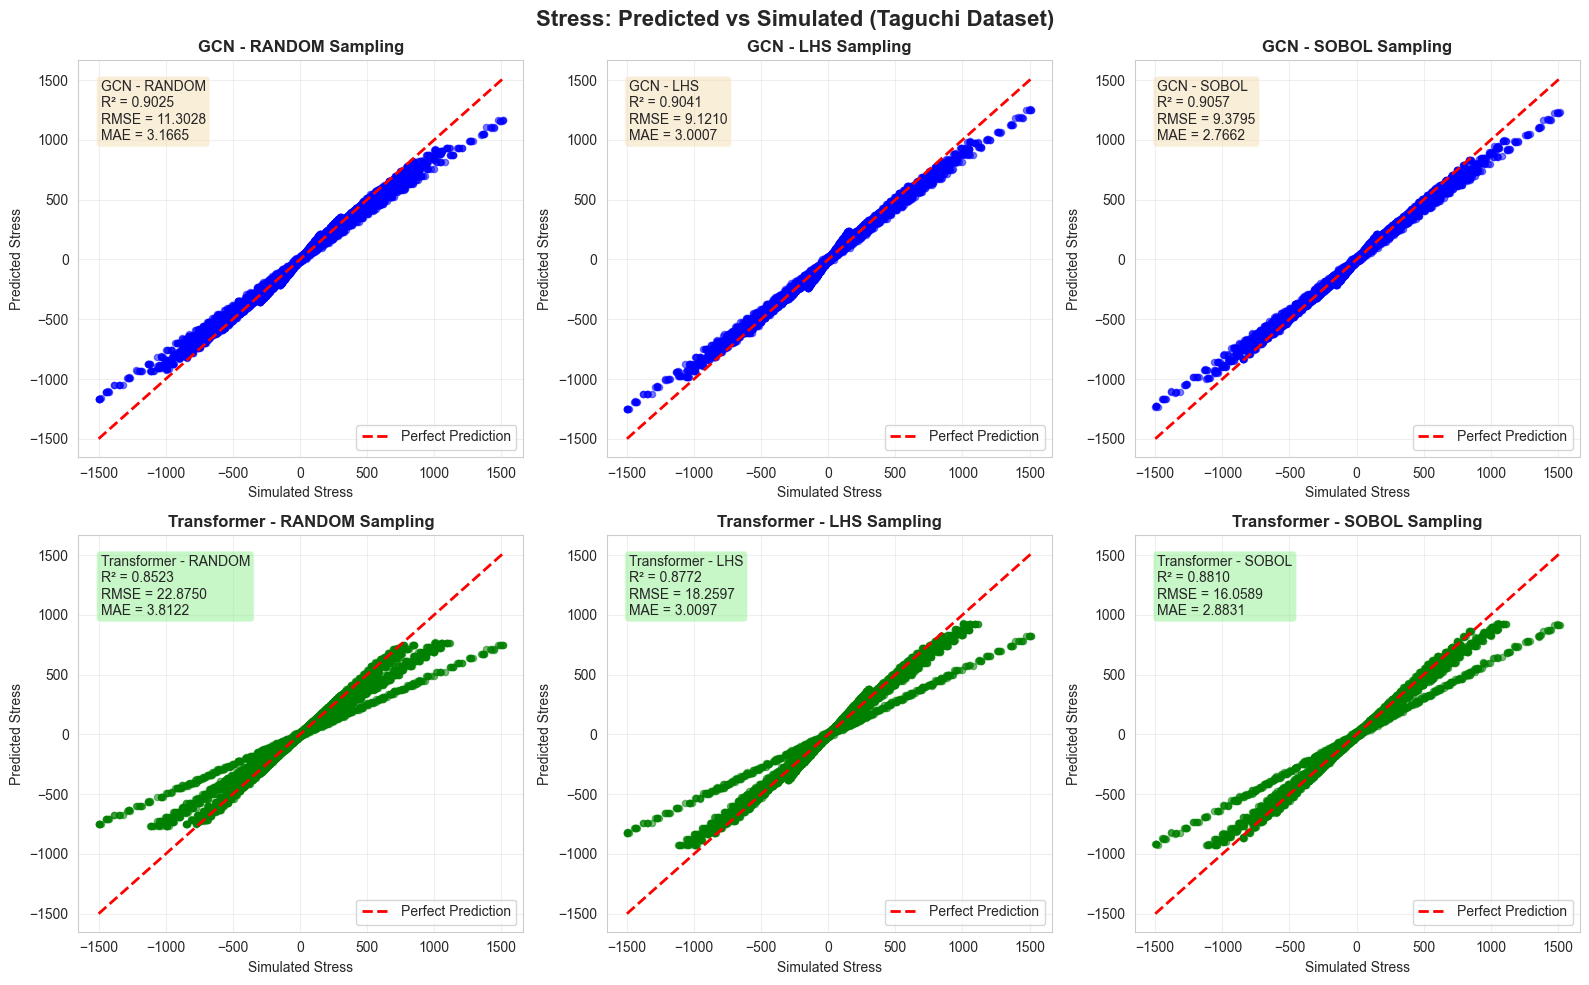

✓ Stress comparison plots saved to: predictions_stress_comparison.png


In [7]:
# Create prediction vs simulated plots for STRESS
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Stress: Predicted vs Simulated (Taguchi Dataset)', fontsize=16, fontweight='bold')
axes = axes.flatten()

for idx, sampling in enumerate(samplings):
    key = f"gcn_{sampling}"
    
    if key in results:
        data = results[key]
        true_vals = data['true_stress']
        pred_vals = data['pred_stress']
        metrics = data['stress_metrics']
        
        ax = axes[idx]
        
        # Flatten for scatter plot
        true_flat = true_vals.flatten()
        pred_flat = pred_vals.flatten()
        
        # Scatter plot
        ax.scatter(true_flat, pred_flat, alpha=0.5, s=20, color='blue')
        
        # Perfect prediction line
        min_val = min(true_flat.min(), pred_flat.min())
        max_val = max(true_flat.max(), pred_flat.max())
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
        
        # Add metrics text
        textstr = f"GCN - {sampling.upper()}\n"
        textstr += f"R² = {metrics['r2']:.4f}\n"
        textstr += f"RMSE = {metrics['rmse']:.4f}\n"
        textstr += f"MAE = {metrics['mae']:.4f}"
        
        ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=10,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        
        ax.set_xlabel('Simulated Stress', fontsize=10)
        ax.set_ylabel('Predicted Stress', fontsize=10)
        ax.set_title(f'GCN - {sampling.upper()} Sampling', fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3)

# Plot transformer models on the right
for idx, sampling in enumerate(samplings):
    key = f"transformer_{sampling}"
    
    if key in results:
        data = results[key]
        true_vals = data['true_stress']
        pred_vals = data['pred_stress']
        metrics = data['stress_metrics']
        
        ax = axes[3 + idx]
        
        # Flatten for scatter plot
        true_flat = true_vals.flatten()
        pred_flat = pred_vals.flatten()
        
        # Scatter plot
        ax.scatter(true_flat, pred_flat, alpha=0.5, s=20, color='green')
        
        # Perfect prediction line
        min_val = min(true_flat.min(), pred_flat.min())
        max_val = max(true_flat.max(), pred_flat.max())
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
        
        # Add metrics text
        textstr = f"Transformer - {sampling.upper()}\n"
        textstr += f"R² = {metrics['r2']:.4f}\n"
        textstr += f"RMSE = {metrics['rmse']:.4f}\n"
        textstr += f"MAE = {metrics['mae']:.4f}"
        
        ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=10,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))
        
        ax.set_xlabel('Simulated Stress', fontsize=10)
        ax.set_ylabel('Predicted Stress', fontsize=10)
        ax.set_title(f'Transformer - {sampling.upper()} Sampling', fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('predictions_stress_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Stress comparison plots saved to: predictions_stress_comparison.png")

## Step 4: Metrics Comparison

Create a summary table and bar charts comparing performance metrics across all models.

In [8]:
# Create metrics summary table
metrics_data = []

for key in sorted(results.keys()):
    model_type, sampling = key.rsplit('_', 1)
    data = results[key]
    disp_m = data['disp_metrics']
    stress_m = data['stress_metrics']
    
    metrics_data.append({
        'Model Type': model_type.upper(),
        'Sampling': sampling.upper(),
        'Disp R²': f"{disp_m['r2']:.4f}",
        'Disp RMSE': f"{disp_m['rmse']:.4f}",
        'Disp MAE': f"{disp_m['mae']:.4f}",
        'Stress R²': f"{stress_m['r2']:.4f}",
        'Stress RMSE': f"{stress_m['rmse']:.4f}",
        'Stress MAE': f"{stress_m['mae']:.4f}",
    })

metrics_df = pd.DataFrame(metrics_data)
print("\n" + "="*120)
print("METRICS SUMMARY TABLE - Taguchi Dataset Evaluation")
print("="*120)
print(metrics_df.to_string(index=False))
print("="*120)

# Store for easy reference
display(metrics_df)


METRICS SUMMARY TABLE - Taguchi Dataset Evaluation
 Model Type Sampling Disp R² Disp RMSE Disp MAE Stress R² Stress RMSE Stress MAE
        GCN      LHS  0.3029    0.7358   0.0938    0.9041      9.1210     3.0007
        GCN   RANDOM  0.3043    0.8130   0.0846    0.9025     11.3028     3.1665
        GCN    SOBOL  0.2963    0.9793   0.1007    0.9057      9.3795     2.7662
TRANSFORMER      LHS  0.2676    1.4267   0.1509    0.8772     18.2597     3.0097
TRANSFORMER   RANDOM  0.2687    1.5645   0.1242    0.8523     22.8750     3.8122
TRANSFORMER    SOBOL  0.2753    1.4638   0.0920    0.8810     16.0589     2.8831


,Model Type,Sampling,Disp R²,Disp RMSE,Disp MAE,Stress R²,Stress RMSE,Stress MAE
0,GCN,LHS,0.3029,0.7358,0.0938,0.9041,9.1210,3.0007
1,GCN,RANDOM,0.3043,0.8130,0.0846,0.9025,11.3028,3.1665
2,GCN,SOBOL,0.2963,0.9793,0.1007,0.9057,9.3795,2.7662
3,TRANSFORMER,LHS,0.2676,1.4267,0.1509,0.8772,18.2597,3.0097
4,TRANSFORMER,RANDOM,0.2687,1.5645,0.1242,0.8523,22.8750,3.8122
5,TRANSFORMER,SOBOL,0.2753,1.4638,0.0920,0.8810,16.0589,2.8831


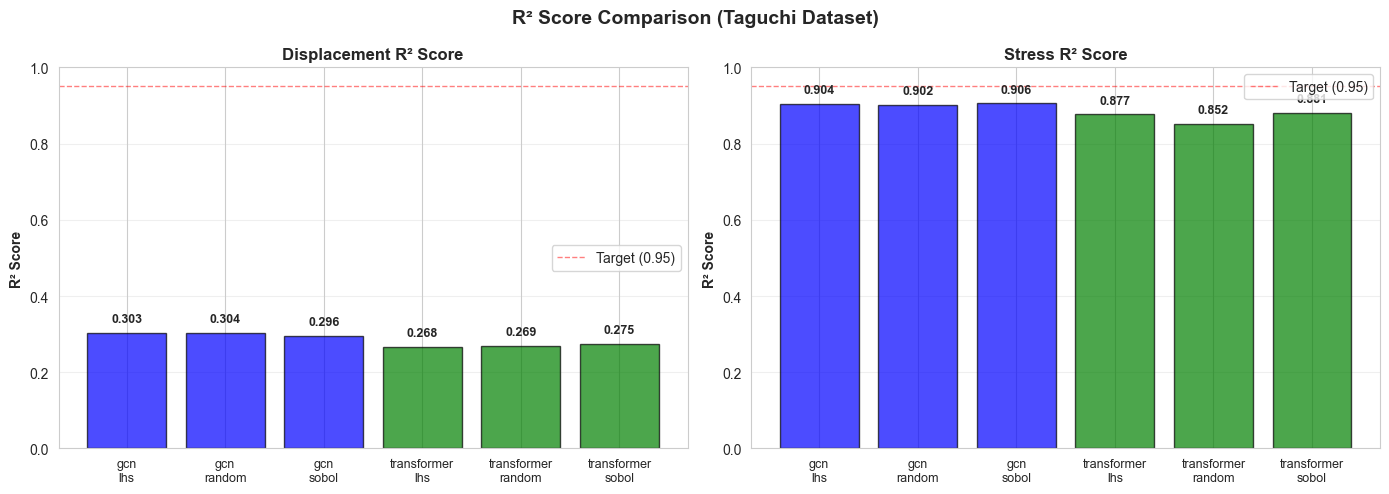

✓ R² comparison plots saved to: metrics_r2_comparison.png


In [9]:
# Create R² comparison bar charts
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('R² Score Comparison (Taguchi Dataset)', fontsize=14, fontweight='bold')

# Extract R² values
disp_r2_values = {}
stress_r2_values = {}

for key in sorted(results.keys()):
    disp_r2_values[key] = results[key]['disp_metrics']['r2']
    stress_r2_values[key] = results[key]['stress_metrics']['r2']

# Displacement R² plot
ax = axes[0]
keys = list(disp_r2_values.keys())
values = list(disp_r2_values.values())
colors = ['blue' if 'gcn' in k else 'green' for k in keys]
labels = [k.replace('_', '\n') for k in keys]

bars = ax.bar(range(len(values)), values, color=colors, alpha=0.7, edgecolor='black')
ax.set_ylabel('R² Score', fontweight='bold')
ax.set_title('Displacement R² Score', fontweight='bold')
ax.set_xticks(range(len(values)))
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylim([0, 1.0])
ax.axhline(y=0.95, color='r', linestyle='--', linewidth=1, alpha=0.5, label='Target (0.95)')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars, values)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
            f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Stress R² plot
ax = axes[1]
values = list(stress_r2_values.values())
colors = ['blue' if 'gcn' in k else 'green' for k in keys]

bars = ax.bar(range(len(values)), values, color=colors, alpha=0.7, edgecolor='black')
ax.set_ylabel('R² Score', fontweight='bold')
ax.set_title('Stress R² Score', fontweight='bold')
ax.set_xticks(range(len(values)))
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylim([0, 1.0])
ax.axhline(y=0.95, color='r', linestyle='--', linewidth=1, alpha=0.5, label='Target (0.95)')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars, values)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
            f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('metrics_r2_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ R² comparison plots saved to: metrics_r2_comparison.png")

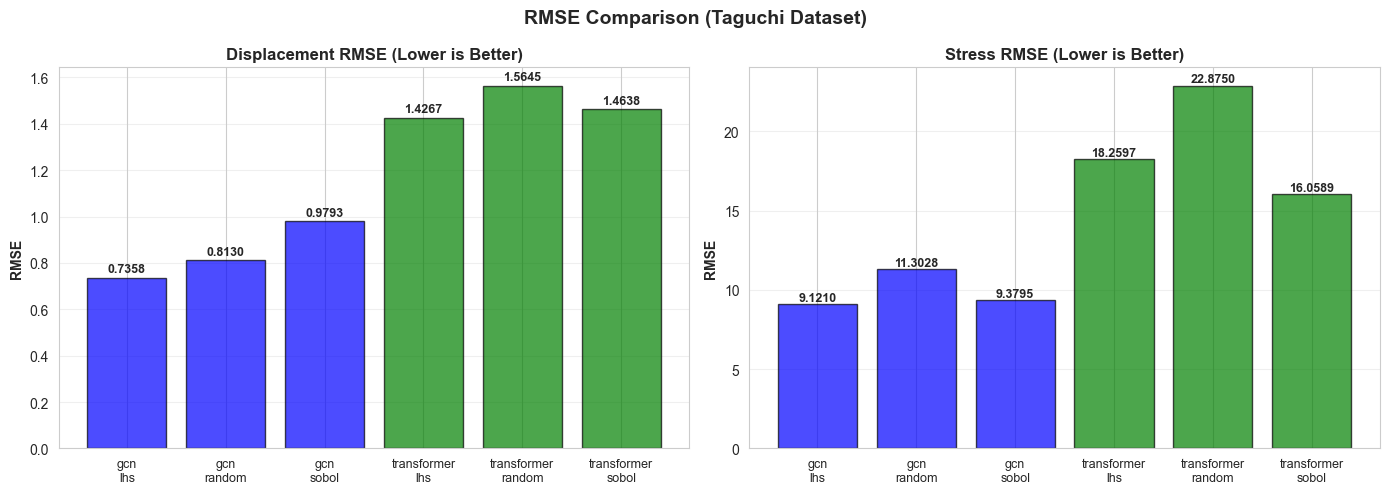

✓ RMSE comparison plots saved to: metrics_rmse_comparison.png


In [10]:
# Create RMSE comparison bar charts
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('RMSE Comparison (Taguchi Dataset)', fontsize=14, fontweight='bold')

# Extract RMSE values
disp_rmse_values = {}
stress_rmse_values = {}

for key in sorted(results.keys()):
    disp_rmse_values[key] = results[key]['disp_metrics']['rmse']
    stress_rmse_values[key] = results[key]['stress_metrics']['rmse']

# Displacement RMSE plot
ax = axes[0]
keys = list(disp_rmse_values.keys())
values = list(disp_rmse_values.values())
colors = ['blue' if 'gcn' in k else 'green' for k in keys]
labels = [k.replace('_', '\n') for k in keys]

bars = ax.bar(range(len(values)), values, color=colors, alpha=0.7, edgecolor='black')
ax.set_ylabel('RMSE', fontweight='bold')
ax.set_title('Displacement RMSE (Lower is Better)', fontweight='bold')
ax.set_xticks(range(len(values)))
ax.set_xticklabels(labels, fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars, values)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
            f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Stress RMSE plot
ax = axes[1]
values = list(stress_rmse_values.values())
colors = ['blue' if 'gcn' in k else 'green' for k in keys]

bars = ax.bar(range(len(values)), values, color=colors, alpha=0.7, edgecolor='black')
ax.set_ylabel('RMSE', fontweight='bold')
ax.set_title('Stress RMSE (Lower is Better)', fontweight='bold')
ax.set_xticks(range(len(values)))
ax.set_xticklabels(labels, fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars, values)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
            f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('metrics_rmse_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ RMSE comparison plots saved to: metrics_rmse_comparison.png")

## Step 5: Error Distribution Analysis

Analyze the distribution of prediction errors for each model.

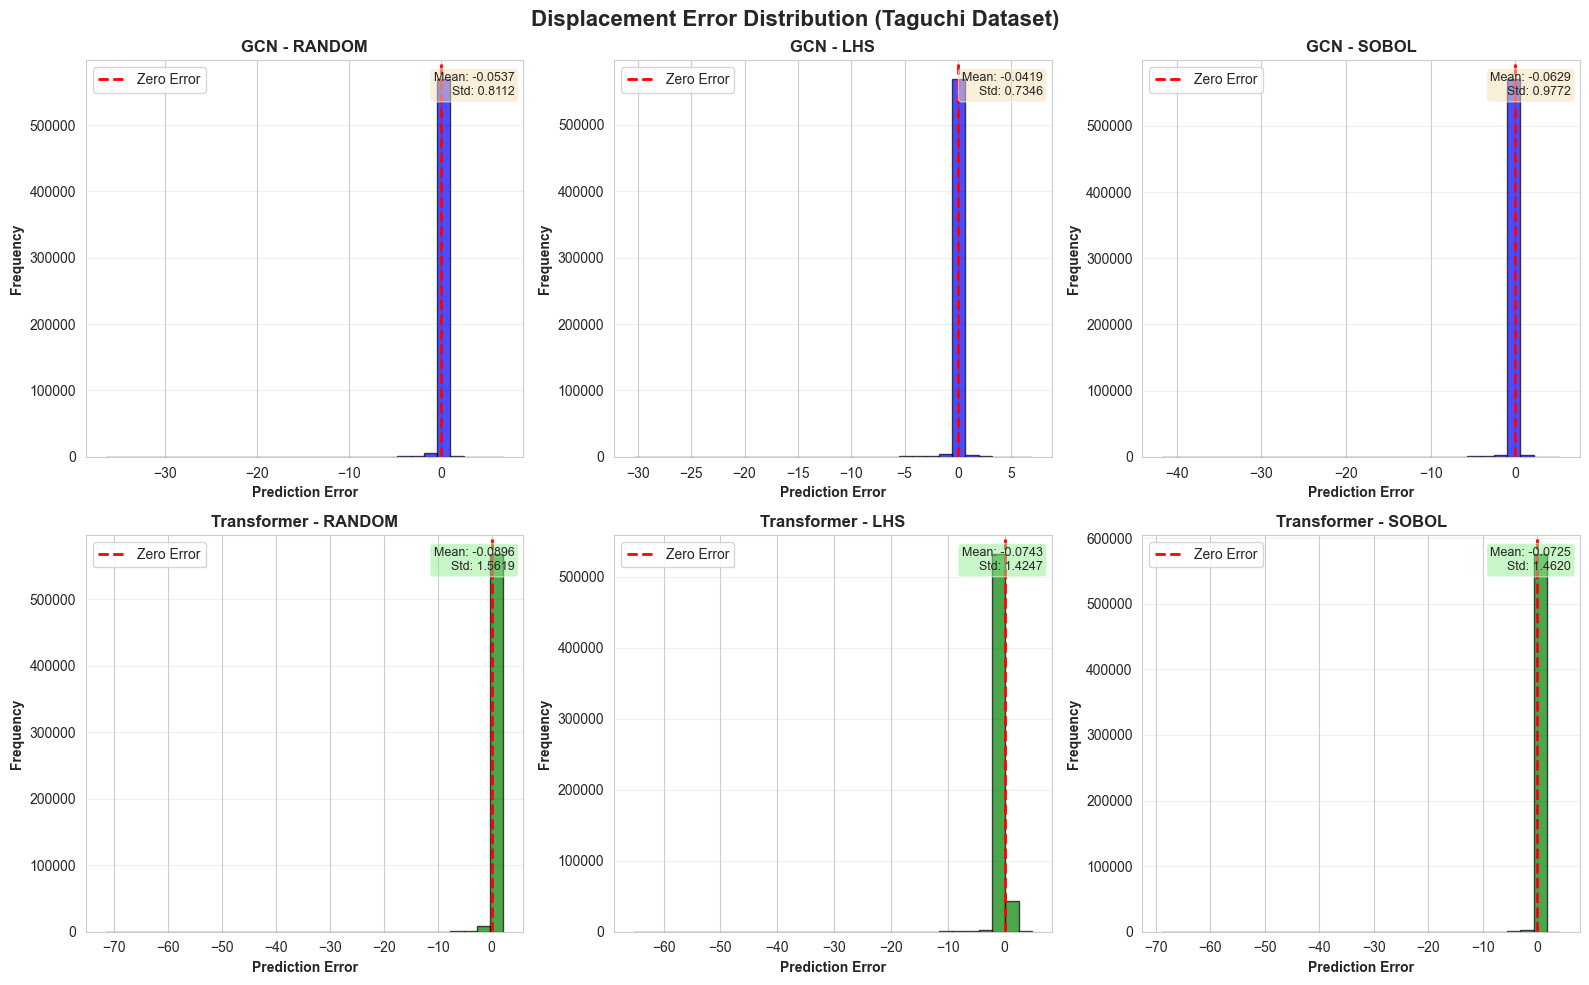

✓ Error distribution plots saved to: error_distribution_displacement.png


In [12]:
# Create error distribution plots
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Displacement Error Distribution (Taguchi Dataset)', fontsize=16, fontweight='bold')
axes = axes.flatten()

for idx, sampling in enumerate(samplings):
    key = f"gcn_{sampling}"
    if key in results:
        data = results[key]
        errors = (data['true_disp'] - data['pred_disp']).flatten()
        
        ax = axes[idx]
        ax.hist(errors, bins=30, color='blue', alpha=0.7, edgecolor='black')
        ax.axvline(x=0, color='r', linestyle='--', linewidth=2, label='Zero Error')
        ax.set_xlabel('Prediction Error', fontweight='bold')
        ax.set_ylabel('Frequency', fontweight='bold')
        ax.set_title(f'GCN - {sampling.upper()}', fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3, axis='y')
        
        # Add stats text
        mean_err = np.mean(errors)
        std_err = np.std(errors)
        textstr = f"Mean: {mean_err:.4f}\nStd: {std_err:.4f}"
        ax.text(0.98, 0.97, textstr, transform=ax.transAxes, fontsize=9,
                verticalalignment='top', horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Plot transformer models
for idx, sampling in enumerate(samplings):
    key = f"transformer_{sampling}"
    
    if key in results:
        data = results[key]
        errors = (data['true_disp'] - data['pred_disp']).flatten()
        
        ax = axes[3 + idx]
        ax.hist(errors, bins=30, color='green', alpha=0.7, edgecolor='black')
        ax.axvline(x=0, color='r', linestyle='--', linewidth=2, label='Zero Error')
        ax.set_xlabel('Prediction Error', fontweight='bold')
        ax.set_ylabel('Frequency', fontweight='bold')
        ax.set_title(f'Transformer - {sampling.upper()}', fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3, axis='y')
        
        # Add stats text
        mean_err = np.mean(errors)
        std_err = np.std(errors)
        textstr = f"Mean: {mean_err:.4f}\nStd: {std_err:.4f}"
        ax.text(0.98, 0.97, textstr, transform=ax.transAxes, fontsize=9,
                verticalalignment='top', horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))

plt.tight_layout()
plt.savefig('error_distribution_displacement.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Error distribution plots saved to: error_distribution_displacement.png")

## Step 6: Summary and Analysis

Performance analysis of trained models on the taguchi dataset.

In [13]:
print("\n" + "="*100)
print("MODEL PERFORMANCE SUMMARY - Taguchi Dataset Evaluation")
print("="*100)

# Rank models by displacement R²
print("\n1. DISPLACEMENT PERFORMANCE (Ranked by R²):")
print("-" * 100)
disp_rankings = sorted([(k, results[k]['disp_metrics']['r2']) for k in results.keys()], 
                        key=lambda x: x[1], reverse=True)
for rank, (model, r2) in enumerate(disp_rankings, 1):
    model_type, sampling = model.rsplit('_', 1)
    metrics = results[model]['disp_metrics']
    print(f"  {rank}. {model_type.upper():12} + {sampling.upper():6} → R²={r2:.4f}, RMSE={metrics['rmse']:.4f}, MAE={metrics['mae']:.4f}")

# Rank models by stress R²
print("\n2. STRESS PERFORMANCE (Ranked by R²):")
print("-" * 100)
stress_rankings = sorted([(k, results[k]['stress_metrics']['r2']) for k in results.keys()], 
                         key=lambda x: x[1], reverse=True)
for rank, (model, r2) in enumerate(stress_rankings, 1):
    model_type, sampling = model.rsplit('_', 1)
    metrics = results[model]['stress_metrics']
    print(f"  {rank}. {model_type.upper():12} + {sampling.upper():6} → R²={r2:.4f}, RMSE={metrics['rmse']:.4f}, MAE={metrics['mae']:.4f}")

# Analysis by model type
print("\n3. AVERAGE PERFORMANCE BY MODEL TYPE:")
print("-" * 100)
for mtype in model_types:
    disp_r2_list = [results[k]['disp_metrics']['r2'] for k in results.keys() if k.startswith(mtype)]
    stress_r2_list = [results[k]['stress_metrics']['r2'] for k in results.keys() if k.startswith(mtype)]
    
    avg_disp_r2 = np.mean(disp_r2_list)
    avg_stress_r2 = np.mean(stress_r2_list)
    
    print(f"  {mtype.upper():12}: Avg Displacement R²={avg_disp_r2:.4f}, Avg Stress R²={avg_stress_r2:.4f}")

# Analysis by sampling strategy
print("\n4. AVERAGE PERFORMANCE BY SAMPLING STRATEGY:")
print("-" * 100)
for sampling in samplings:
    disp_r2_list = [results[k]['disp_metrics']['r2'] for k in results.keys() if k.endswith(sampling)]
    stress_r2_list = [results[k]['stress_metrics']['r2'] for k in results.keys() if k.endswith(sampling)]
    
    avg_disp_r2 = np.mean(disp_r2_list)
    avg_stress_r2 = np.mean(stress_r2_list)
    
    print(f"  {sampling.upper():6}: Avg Displacement R²={avg_disp_r2:.4f}, Avg Stress R²={avg_stress_r2:.4f}")

print("\n" + "="*100)
print("KEY FINDINGS:")
print("="*100)
print(f"  ✓ Total models evaluated: {len(results)}")
print(f"  ✓ Best displacement model: {disp_rankings[0][0].replace('_', ' ').upper()}")
print(f"  ✓ Best stress model: {stress_rankings[0][0].replace('_', ' ').upper()}")
print(f"  ✓ All metrics saved to: predictions_*_comparison.png, metrics_*_comparison.png")
print("="*100)


MODEL PERFORMANCE SUMMARY - Taguchi Dataset Evaluation

1. DISPLACEMENT PERFORMANCE (Ranked by R²):
----------------------------------------------------------------------------------------------------
  1. GCN          + RANDOM → R²=0.3043, RMSE=0.8130, MAE=0.0846
  2. GCN          + LHS    → R²=0.3029, RMSE=0.7358, MAE=0.0938
  3. GCN          + SOBOL  → R²=0.2963, RMSE=0.9793, MAE=0.1007
  4. TRANSFORMER  + SOBOL  → R²=0.2753, RMSE=1.4638, MAE=0.0920
  5. TRANSFORMER  + RANDOM → R²=0.2687, RMSE=1.5645, MAE=0.1242
  6. TRANSFORMER  + LHS    → R²=0.2676, RMSE=1.4267, MAE=0.1509

2. STRESS PERFORMANCE (Ranked by R²):
----------------------------------------------------------------------------------------------------
  1. GCN          + SOBOL  → R²=0.9057, RMSE=9.3795, MAE=2.7662
  2. GCN          + LHS    → R²=0.9041, RMSE=9.1210, MAE=3.0007
  3. GCN          + RANDOM → R²=0.9025, RMSE=11.3028, MAE=3.1665
  4. TRANSFORMER  + SOBOL  → R²=0.8810, RMSE=16.0589, MAE=2.8831
  5. TRANSFORMER